In [1]:
import re
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

class TextState(TypedDict):
    raw_text: str
    cleaned: str
    word_count: int
    summary: str

def claean_text(state: TextState) -> dict:
    cleaned = re.sub(r'\s+', ' ', state["raw_text"].strip()).lower()
    return {"cleaned": cleaned}

def count_words(state: TextState) -> dict:
    return {"word_count": len(state["cleaned"].split())}

def format_result(state: TextState) -> dict:
    preview = state['cleaned'][:50] + (
        '...' if len(state['cleaned']) > 50 else ''
    )

    summary = (
        "=== text analysis summary ===\n"
        f"Words count : {state['word_count']}\n"
        f"Preview     : {preview}\n"
    )

    return {"summary": summary}

builder = StateGraph(TextState)

builder.add_node("claean_text", claean_text)
builder.add_node("count_words", count_words)
builder.add_node("format_result", format_result)

builder.add_edge(START, "claean_text")
builder.add_edge("claean_text", "count_words")
builder.add_edge("count_words", "format_result")
builder.add_edge("format_result", END)

graph = builder.compile()

In [4]:

result = graph.invoke({
    "raw_text": "Oracle Java is the #1 programming language and development platform."
})



In [5]:
print(result["summary"])

=== text analysis summary ===
Words count : 10
Preview     : oracle java is the #1 programming language and dev...



In [18]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END


class StateTest(TypedDict):
    steps : list

def state_one(state : StateTest) -> dict:
    current_state= state["steps"]
    state["steps"] = current_state + ["state_one"]
    return state
     
def state_two(state : StateTest) -> dict:
    current_state= state["steps"]
    state["steps"] = current_state + ["state_two"]
    return state

builder = StateGraph(StateTest)
builder.add_node("state_one",state_one)
builder.add_node("state_two",state_two)
builder.add_edge(START, "state_one")
builder.add_edge( "state_one","state_two")
builder.add_edge( "state_two", END)



In [19]:
graph= builder.compile()

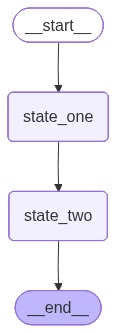

In [15]:
graph

In [20]:
result=graph.invoke({"steps":["start"]})

In [21]:
result

{'steps': ['start', 'state_one', 'state_two']}

### Reducer

In [48]:
from typing import TypedDict, Annotated
from operator import add
from langgraph.graph import START, END,  StateGraph

class ReducerState(TypedDict):
    step: Annotated[list, add]


def state_one(state : ReducerState) -> dict:
    current_state= state["step"]
    state["step"] = current_state + ["state_one"]
    print("state_one",state["step"])
    return state
     
def state_two(state : ReducerState) -> dict:
    current_state= state["step"]
    state["step"] = current_state + ["state_two"]
    print("state_two",state["step"])
    return state

builder = StateGraph(ReducerState)
builder.add_node("state_one",state_one)
builder.add_node("state_two",state_two)
builder.add_edge(START, "state_one")
builder.add_edge( "state_one","state_two")
builder.add_edge( "state_two", END)

reducerStateGraph =builder.compile()

In [49]:
result2 = reducerStateGraph.invoke({"step":["start"]})

state_one ['start', 'state_one']
state_two ['start', 'start', 'state_one', 'state_two']


In [47]:
result2["step"]

['start', 'start', 'state_one', 'start', 'start', 'state_one', 'state_two']

In [57]:
from typing import TypedDict, Literal
from langgraph.graph import START, END, StateGraph

class Num_State(TypedDict):
    number : int
    result: str

def odd_event_check(state : Num_State) -> Literal["odd","even"]:
    number = state["number"]
    if number % 2 == 0 :
        return "even"
    else:
        return "odd"


def receive_input(state : Num_State):
    print(f"",{state["number"]})
    

def odd_node(state : Num_State) -> dict:
    msg =f"{state['number']} is ODD"
    return {"result": {msg}}


def even_node(state : Num_State) -> dict:
    msg =f"{state['number']} is EVEN"
    return {"result": {msg}}

builder = StateGraph(Num_State)

builder.add_node("receive_input", receive_input)
builder.add_node("odd_node", odd_node)
builder.add_node("even_node", even_node)

builder.add_edge(START, "receive_input")

builder.add_conditional_edges(
    "receive_input", odd_event_check, 
    {
        "odd"  : "odd_node",
        "even" : "even_node"
    }
)

builder.add_edge("odd_node", END)
builder.add_edge("even_node", END)


In [58]:
graph_cond = builder.compile()

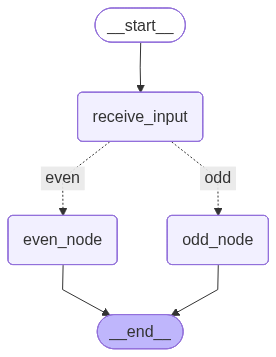

In [59]:
graph_cond

In [60]:
response = graph_cond.invoke({"number":1,"result":""})

 {1}


In [62]:
print(response["result"])

{'1 is ODD'}


In [63]:
response2 = graph_cond.invoke({"number":2,"result":""})

 {2}


In [64]:
print(response2["result"])

{'2 is EVEN'}


### Tool Calling

In [4]:
import os
from dotenv import load_dotenv

load_dotenv()

token = os.getenv("OPENAI_API_KEY")





In [13]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model = "gpt-4o-mini")

In [ ]:
from langchain_core.tools import tool

@tool
def add(a: float, b: float) -> float:
    """To add two numbers """
    print("add called")
    return a+b

@tool
def weather_update(city : str) -> str:
    """ to get the weather update for the city provided"""
    data = {
        "chennai": "sunny",
        "mumbai" : "Hot",
        "hydrabat" : "cloudy"
    }
    print("wether_update called")
    return data.get(city.lower(), "Weather data not available for this city.")

tools = [add, weather_update]





In [14]:
llm_with_tools = llm.bind_tools(tools)

In [17]:
from langgraph.graph import START, END, StateGraph, MessagesState
from langgraph.prebuilt import ToolNode, tools_condition


def chat_bot(state : MessagesState) -> dict:
    message = state["messages"]
    response = llm_with_tools.invoke(message)
    return {"messages":response}

builder = StateGraph(MessagesState)

tool_node = ToolNode(tools)

builder.add_node( "chat_bot", chat_bot)
builder.add_node("tools", tool_node)

builder.add_edge(START, "chat_bot")

builder.add_conditional_edges("chat_bot", tools_condition)

builder.add_edge("tools","chat_bot")




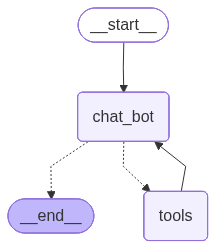

In [19]:
graph = builder.compile()
graph

In [20]:
from langchain.messages import HumanMessage

msg = HumanMessage("what is the weather in chennai")

result = graph.invoke({"messages": [msg]})

wether_update called


KeyError: 'Chennai'

In [16]:
print(result)

{'messages': [HumanMessage(content='what is the weather in chennai', additional_kwargs={}, response_metadata={}, id='a8b8b948-cc74-4cd2-abfa-d56e076f2056')]}
